In [ ]:
from pathlib import Path
import xarray as xr
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import xesmf as xe
import time
from dask.distributed import Client

In [ ]:
client = Client()

In [ ]:
client.close()

In [ ]:
time.strftime("%H:%M:%S", time.gmtime(1200))

'00:20:00'

In [ ]:
daymetpath = Path("/Volumes/cwdata1/Daymet/")
era5dscpath = Path().absolute().parents[1]/'dyndowndata/DSCALE_data'
regridderpath = Path().absolute().parents[0]/'evaluation/regridders'

In [ ]:
template_4km = xr.open_dataset(era5dscpath/'era5_wrf_dscale_4km_2014-12-22.nc', chunks='auto')
template_4km = template_4km.rename({"XLONG": "lon", "XLAT": "lat", 'XTIME': 'time'})

template_12km = xr.open_dataset(era5dscpath/'era5_wrf_dscale_12km_2014-12-22.nc', chunks='auto')
template_12km = template_12km.rename({"XLONG": "lon", "XLAT": "lat", 'XTIME': 'time'})


In [ ]:
template_12km["lat"].attrs["standard_name"] = "latitude"
template_12km["lat"].attrs["units"] = "degrees_north"
template_12km["lon"].attrs["standard_name"] = "longitude"
template_12km["lon"].attrs["units"] = "degrees_east"

In [ ]:
template_12km

<xarray.Dataset> Size: 683MB
Dimensions:       (Time: 24, south_north: 204, west_east: 264, interp_level: 9,
                   soil_layers_stag: 4)
Coordinates:
  * Time          (Time) datetime64[ns] 192B 2014-12-22 ... 2014-12-22T23:00:00
    lon           (south_north, west_east) float32 215kB dask.array<chunksize=(204, 264), meta=np.ndarray>
    lat           (south_north, west_east) float32 215kB dask.array<chunksize=(204, 264), meta=np.ndarray>
    time          (Time) float32 96B dask.array<chunksize=(24,), meta=np.ndarray>
  * interp_level  (interp_level) float64 72B 200.0 300.0 500.0 ... 950.0 1e+03
Dimensions without coordinates: south_north, west_east, soil_layers_stag
Data variables: (12/43)
    slp           (Time, south_north, west_east) float32 5MB dask.array<chunksize=(24, 204, 264), meta=np.ndarray>
    ctt           (Time, south_north, west_east) float32 5MB dask.array<chunksize=(24, 204, 264), meta=np.ndarray>
    dbz           (Time, interp_level, south_north, west_east) float32 47MB dask.array<chunksize=(24, 9, 204, 264), meta=np.ndarray>
    rh2           (Time, south_north, west_east) float32 5MB dask.array<chunksize=(24, 204, 264), meta=np.ndarray>
    T2            (Time, south_north, west_east) float32 5MB dask.array<chunksize=(24, 204, 264), meta=np.ndarray>
    Q2            (Time, south_north, west_east) float32 5MB dask.array<chunksize=(24, 204, 264), meta=np.ndarray>
    ...            ...
    u             (Time, interp_level, south_north, west_east) float32 47MB dask.array<chunksize=(24, 9, 204, 264), meta=np.ndarray>
    v             (Time, interp_level, south_north, west_east) float32 47MB dask.array<chunksize=(24, 9, 204, 264), meta=np.ndarray>
    w             (Time, interp_level, south_north, west_east) float32 47MB dask.array<chunksize=(24, 9, 204, 264), meta=np.ndarray>
    rainnc        (Time, south_north, west_east) float32 5MB dask.array<chunksize=(24, 204, 264), meta=np.ndarray>
    rainc         (Time, south_north, west_east) float32 5MB dask.array<chunksize=(24, 204, 264), meta=np.ndarray>
    acsnow        (Time, south_north, west_east) float32 5MB dask.array<chunksize=(24, 204, 264), meta=np.ndarray>
Attributes:
    date:     2024-01-18T22:58:32.281312
    data:     Downscaled ERA5 using WRF
    info:     Alaska Climate Adaptation Science Center, University of Alaska ...
    contact:  cwaigl@alaska.edu
    version:  WRF V4.5.1 - project v. 1.1

In [ ]:
daymet_sample = sorted(list(daymetpath.glob('daymet_v4_daily_na_tmin_*.nc')))[0]

In [ ]:
daymet_sampleDS = xr.open_dataset(daymet_sample, chunks='auto')
daymet_sampleDS

<xarray.Dataset> Size: 93GB
Dimensions:                  (time: 365, nv: 2, y: 8075, x: 7814)
Coordinates:
  * x                        (x) float32 31kB -4.56e+06 -4.559e+06 ... 3.253e+06
  * y                        (y) float32 32kB 4.984e+06 4.983e+06 ... -3.09e+06
    lat                      (y, x) float32 252MB dask.array<chunksize=(5050, 4885), meta=np.ndarray>
    lon                      (y, x) float32 252MB dask.array<chunksize=(5050, 4885), meta=np.ndarray>
  * time                     (time) datetime64[ns] 3kB 1981-01-01T12:00:00 .....
Dimensions without coordinates: nv
Data variables:
    yearday                  (time) int16 730B dask.array<chunksize=(365,), meta=np.ndarray>
    time_bnds                (time, nv) datetime64[ns] 6kB dask.array<chunksize=(365, 2), meta=np.ndarray>
    lambert_conformal_conic  int16 2B ...
    tmin                     (time, y, x) float32 92GB dask.array<chunksize=(3, 3000, 3000), meta=np.ndarray>
Attributes:
    start_year:        1981
    source:            Daymet Software Version 4.0
    Version_software:  Daymet Software Version 4.0
    Version_data:      Daymet Data Version 4.0
    Conventions:       CF-1.6
    citation:          Please see http://daymet.ornl.gov/ for current Daymet ...
    references:        Please see http://daymet.ornl.gov/ for current informa...

In [ ]:
dataArray = daymet_sampleDS['tmin']
dataArray

<xarray.DataArray 'tmin' (time: 365, y: 8075, x: 7814)> Size: 92GB
dask.array<open_dataset-tmin, shape=(365, 8075, 7814), dtype=float32, chunksize=(3, 3000, 3000), chunktype=numpy.ndarray>
Coordinates:
  * x        (x) float32 31kB -4.56e+06 -4.559e+06 ... 3.252e+06 3.253e+06
  * y        (y) float32 32kB 4.984e+06 4.983e+06 ... -3.089e+06 -3.09e+06
    lat      (y, x) float32 252MB dask.array<chunksize=(5050, 4885), meta=np.ndarray>
    lon      (y, x) float32 252MB dask.array<chunksize=(5050, 4885), meta=np.ndarray>
  * time     (time) datetime64[ns] 3kB 1981-01-01T12:00:00 ... 1981-12-31T12:...
Attributes:
    long_name:     daily minimum temperature
    units:         degrees C
    grid_mapping:  lambert_conformal_conic
    cell_methods:  area: mean time: minimum

-4560250.0 3252750.0 -3090000.0 4984000.0


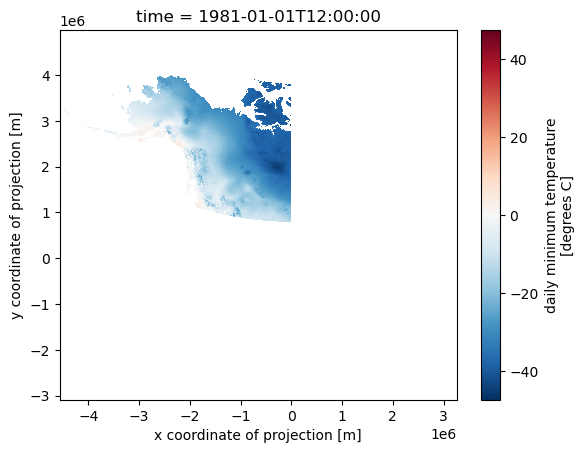

In [ ]:
mask_in = (daymet_sampleDS.lat > 50) & (daymet_sampleDS.lat < 76) & (daymet_sampleDS.lon < -100)
xmin = daymet_sampleDS.where(mask_in).x.min().item()
xmax = daymet_sampleDS.where(mask_in).x.max().item()
ymin = daymet_sampleDS.where(mask_in).y.min().item()
ymax = daymet_sampleDS.where(mask_in).y.max().item()
print(xmin, xmax, ymin, ymax)

dataArray.where(mask_in).isel(time=0).plot()

-4560250.0 3252750.0 -3090000.0 4984000.0


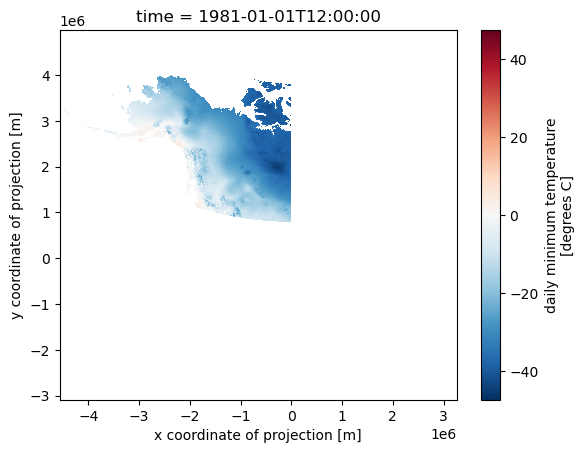

In [ ]:
mask_in = (dataArray.lat > 50) & (dataArray.lat < 76) & (dataArray.lon < -100)
xmin = dataArray.where(mask_in).x.min().item()
xmax = dataArray.where(mask_in).x.max().item()
ymin = dataArray.where(mask_in).y.min().item()
ymax = dataArray.where(mask_in).y.max().item()
print(xmin, xmax, ymin, ymax)

dataArray.where(mask_in).isel(time=0).plot()


In [ ]:
daymet_sample_cropped = daymet_sampleDS.where(
    (daymet_sampleDS.lat > 50) & (daymet_sampleDS.lat < 76) & (daymet_sampleDS.lon < -100))

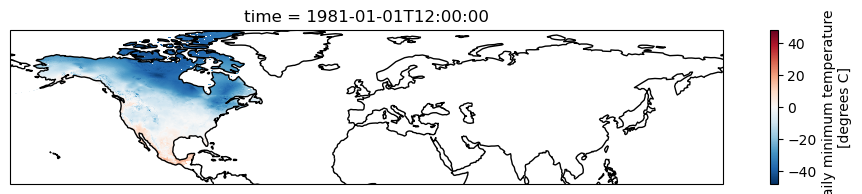

In [ ]:
plt.figure(figsize=(12, 2))
ax = plt.axes(projection=ccrs.PlateCarree())
dataArray.isel(time=0).plot.pcolormesh(ax=ax, x="lon", y="lat")
ax.coastlines()

In [ ]:
regrid_daymet_to_era5DSCALE = xe.Regridder(daymet_sample_cropped, template_12km, method='bilinear', parallel=True)

python(34756) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(34757) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(34758) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [ ]:
regrid_daymet_to_era5DSCALE.to_netcdf("regrid_daymet_to_era5_12km.nc")

'regrid_daymet_to_era5_12km.nc'

In [ ]:
regrid_daymet_to_era5DSCALE

xESMF Regridder 
Regridding algorithm:       bilinear 
Weight filename:            bilinear_8075x7814_204x264.nc 
Reuse pre-computed weights? False 
Input grid shape:           (8075, 7814) 
Output grid shape:          (204, 264) 
Periodic in longitude?      False

In [ ]:
regrid_12km = regrid_daymet_to_era5DSCALE(daymet_sampleDS.tmin)
regrid_12km

<xarray.DataArray (time: 365, south_north: 204, west_east: 264)> Size: 79MB
dask.array<astype, shape=(365, 204, 264), dtype=float32, chunksize=(3, 204, 264), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 1981-01-01T12:00:00 ... 1981-12-31T12:...
    lon      (south_north, west_east) float32 215kB dask.array<chunksize=(204, 264), meta=np.ndarray>
    lat      (south_north, west_east) float32 215kB dask.array<chunksize=(204, 264), meta=np.ndarray>
Dimensions without coordinates: south_north, west_east
Attributes:
    regrid_method:  bilinear

In [ ]:
daymet_regridder = xe.Regridder(daymet_sampleDS, template_12km, method='bilinear', weights= regridderpath / 'regridder_daymet_to_era5_12km.nc', parallel=True)

In [ ]:
daymet_regridder

xESMF Regridder 
Regridding algorithm:       bilinear 
Weight filename:            bilinear_8075x7814_204x264.nc 
Reuse pre-computed weights? False 
Input grid shape:           (8075, 7814) 
Output grid shape:          (204, 264) 
Periodic in longitude?      False

In [ ]:
tmin_regridded = daymet_regridder(daymet_sampleDS.tmin, keep_attrs=True)

In [ ]:
tmin_regridded

<xarray.DataArray 'tmin' (time: 365, south_north: 204, west_east: 264)> Size: 79MB
dask.array<astype, shape=(365, 204, 264), dtype=float32, chunksize=(3, 204, 264), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 1981-01-01T12:00:00 ... 1981-12-31T12:...
    lon      (south_north, west_east) float32 215kB dask.array<chunksize=(204, 264), meta=np.ndarray>
    lat      (south_north, west_east) float32 215kB dask.array<chunksize=(204, 264), meta=np.ndarray>
Dimensions without coordinates: south_north, west_east
Attributes:
    long_name:      daily minimum temperature
    units:          degrees C
    grid_mapping:   lambert_conformal_conic
    cell_methods:   area: mean time: minimum
    regrid_method:  bilinear

In [ ]:
regrid_12km.to_netcdf("daymet_tmin_sample_regridded_to_era5_12km.nc")

KeyboardInterrupt: 